In [1]:
# ============================================
# CELDA 0: Instalación y configuración inicial
# ============================================

!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!pip install -q pyspark==3.5.0 findspark pandas matplotlib seaborn

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import *
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import *
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql.window import Window

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder \
    .appName("SIPSA_ML") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("✅ Spark versión:", spark.version)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.
✅ Spark versión: 3.5.0


In [3]:
# ============================================
# CELDA 1: Cargar dataset SIPSA (mismo del Bloque 1)
# ============================================

ruta_dataset = "/content/drive/MyDrive/Marchine learning/BaseDatos-SIPSA_P-Mensual-2013_2017/Mensual_2013_2017.csv"  # Ajusta tu ruta

df_sipsa = spark.read.csv(
    ruta_dataset,
    header=True,
    inferSchema=True,
    sep=";",
    encoding="ISO-8859-1",
    multiLine=True
)

# Crear columnas derivadas (mismas del Bloque 1)
df_sipsa = df_sipsa.withColumn("Fecha_Date", F.to_date(F.col("Fecha"), "d/MM/yyyy"))
df_sipsa = df_sipsa.withColumn("anio", F.year("Fecha_Date"))
df_sipsa = df_sipsa.withColumn("mes", F.month("Fecha_Date"))
df_sipsa = df_sipsa.withColumn("trimestre", F.quarter("Fecha_Date"))

df_sipsa = df_sipsa.withColumn(
    "Ciudad",
    F.when(F.col("Fuente").contains(","),
           F.trim(F.split(F.col("Fuente"), ",").getItem(0)))
     .otherwise(F.col("Fuente"))
)

print(f"✅ Dataset cargado: {df_sipsa.count():,} registros")
df_sipsa.printSchema()

✅ Dataset cargado: 281,386 registros
root
 |-- Fecha: string (nullable = true)
 |-- Grupo: string (nullable = true)
 |-- Producto: string (nullable = true)
 |-- Fuente: string (nullable = true)
 |-- Precio: integer (nullable = true)
 |-- Fecha_Date: date (nullable = true)
 |-- anio: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- trimestre: integer (nullable = true)
 |-- Ciudad: string (nullable = true)



# PARTE A: PREPARACIÓN DE DATOS (Tareas 7-8)

In [4]:
# ============================================
# TAREA 7: Pipeline de preparación con VectorAssembler, StringIndexer, OneHotEncoder
# ============================================

print("=" * 70)
print("PARTE A - TAREA 7: PIPELINE DE PREPARACIÓN")
print("=" * 70)

# ---------------------------------------------------------
# DEFINIR VARIABLE OBJETIVO (Tarea 13 adelantada)
# ---------------------------------------------------------
# Clasificación: ¿El precio está por encima de la mediana de su grupo?
# Esto crea una variable binaria balanceada y con sentido analítico

mediana_por_grupo = df_sipsa.approxQuantile("Precio", [0.5], 0.01)[0]
print(f"Mediana global del precio: ${mediana_por_grupo:,.0f}")

# Calcular mediana por grupo para clasificación más justa
mediana_grupo = df_sipsa.groupBy("Grupo").agg(
    F.expr("percentile_approx(Precio, 0.5)").alias("mediana_grupo")
)

df_ml = df_sipsa.join(mediana_grupo, "Grupo") \
    .withColumn(
        "label",
        F.when(F.col("Precio") > F.col("mediana_grupo"), 1.0).otherwise(0.0)
    )

print("\n📊 Distribución de clases (label):")
df_ml.groupBy("label").count().show()

# ---------------------------------------------------------
# INDEXAR VARIABLES CATEGÓRICAS
# ---------------------------------------------------------

# Variables categóricas a indexar
categorical_cols = ["Grupo", "Ciudad", "Producto"]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

# One-Hot Encoding para Grupo y Ciudad (alta cardinalidad)
encoders = [
    OneHotEncoder(inputCol="Grupo_idx", outputCol="Grupo_ohe"),
    OneHotEncoder(inputCol="Ciudad_idx", outputCol="Ciudad_ohe")
]

# ---------------------------------------------------------
# VARIABLES NUMÉRICAS
# ---------------------------------------------------------

numeric_cols = ["anio", "mes", "trimestre"]

# ---------------------------------------------------------
# VECTOR ASSEMBLER
# ---------------------------------------------------------

assembler = VectorAssembler(
    inputCols=["Grupo_ohe", "Ciudad_ohe", "Producto_idx"] + numeric_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

# ---------------------------------------------------------
# CONSTRUIR PIPELINE
# ---------------------------------------------------------

pipeline_prep = Pipeline(stages=indexers + encoders + [assembler])

print("✅ Pipeline de preparación definido")
print(f"   Etapas: {len(pipeline_prep.getStages())}")
print(f"   - Indexadores: {len(indexers)}")
print(f"   - Encoders: {len(encoders)}")
print(f"   - Assembler: 1")

PARTE A - TAREA 7: PIPELINE DE PREPARACIÓN
Mediana global del precio: $2,450

📊 Distribución de clases (label):
+-----+------+
|label| count|
+-----+------+
|  0.0|141530|
|  1.0|139856|
+-----+------+

✅ Pipeline de preparación definido
   Etapas: 6
   - Indexadores: 3
   - Encoders: 2
   - Assembler: 1


In [5]:
# ============================================
# TAREA 8: Estandarización con StandardScaler (justificación incluida)
# ============================================

print("\n" + "=" * 70)
print("PARTE A - TAREA 8: ESTANDARIZACIÓN")
print("=" * 70)

"""
JUSTIFICACIÓN: Se usa StandardScaler en lugar de MinMaxScaler porque:
1. PCA (Parte B) requiere variables centradas en la media para calcular
   componentes principales correctamente.
2. K-Means es sensible a la escala; StandardScaler maneja mejor outliers.
3. Regresión Logística converge más rápido con features estandarizados.
4. Las variables numéricas (año, mes) y las one-hot tienen escalas muy
   diferentes, lo que sesgaría los modelos sin estandarización.
"""

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,      # Dividir por desviación estándar
    withMean=True      # Restar media (necesario para PCA)
)

# Pipeline completo: preparación + escalamiento
pipeline_completo = Pipeline(stages=pipeline_prep.getStages() + [scaler])

# Ajustar y transformar
modelo_pipeline = pipeline_completo.fit(df_ml)
df_prepared = modelo_pipeline.transform(df_ml)

# Verificar resultado
print("✅ Datos preparados y estandarizados")
print(f"   Dimensiones del vector features: {len(df_prepared.select('features').first()[0])}")

# Mostrar estadísticas del vector estandarizado
from pyspark.ml.functions import vector_to_array
df_prepared.select(
    F.min(vector_to_array("features")[0]).alias("min_f1"),
    F.max(vector_to_array("features")[0]).alias("max_f1"),
    F.avg(vector_to_array("features")[0]).alias("mean_f1")
).show()

print("\n📊 Muestra de features preparados:")
df_prepared.select("Grupo", "Ciudad", "anio", "Precio", "label", "features").show(5, truncate=True)


PARTE A - TAREA 8: ESTANDARIZACIÓN
✅ Datos preparados y estandarizados
   Dimensiones del vector features: 80
+-------------------+------------------+--------------------+
|             min_f1|            max_f1|             mean_f1|
+-------------------+------------------+--------------------+
|-0.5841477919599601|1.7118894566179685|-5.81697034556850...|
+-------------------+------------------+--------------------+


📊 Muestra de features preparados:
+------+------------+----+------+-----+--------------------+
| Grupo|      Ciudad|anio|Precio|label|            features|
+------+------------+----+------+-----+--------------------+
|CARNES|Barranquilla|2013|  3073|  0.0|[-0.5841477919599...|
|CARNES|Barranquilla|2013|  3067|  0.0|[-0.5841477919599...|
|CARNES|      Bogotá|2013|  2967|  0.0|[-0.5841477919599...|
|CARNES|      Bogotá|2013|  2560|  0.0|[-0.5841477919599...|
|CARNES|   Cartagena|2013|  3429|  0.0|[-0.5841477919599...|
+------+------------+----+------+-----+----------------

# PARTE B: APRENDIZAJE NO SUPERVISADO (Tareas 9-12)

In [6]:
# ============================================
# TAREA 9: PCA - Análisis de Componentes Principales
# ============================================

print("\n" + "=" * 70)
print("PARTE B - TAREA 9: PCA")
print("=" * 70)

# Usar muestra para velocidad (PCA en 280k registros es lento)
df_pca_sample = df_prepared.sample(False, 0.3, seed=42)

# Aplicar PCA con k=10 para evaluar
pca = PCA(k=10, inputCol="features", outputCol="pca_features")
model_pca = pca.fit(df_pca_sample)
df_pca = model_pca.transform(df_pca_sample)

# Varianza explicada por componente
varianza = model_pca.explainedVariance.toArray()

print("\n📊 Varianza explicada por componente:")
print(f"{'Componente':>12s} {'Varianza':>12s} {'% Acumulado':>12s} {'Gráfico'}")
print("-" * 60)

varianza_acum = np.cumsum(varianza)
for i, (v, va) in enumerate(zip(varianza, varianza_acum)):
    barra = "█" * int(v * 100)
    print(f"PC{i+1:>3d}:       {v:>10.4f}   {va*100:>10.2f}%   {barra}")


PARTE B - TAREA 9: PCA

📊 Varianza explicada por componente:
  Componente     Varianza  % Acumulado Gráfico
------------------------------------------------------------
PC  1:           0.0253         2.53%   ██
PC  2:           0.0213         4.67%   ██
PC  3:           0.0212         6.79%   ██
PC  4:           0.0186         8.65%   █
PC  5:           0.0177        10.42%   █
PC  6:           0.0173        12.15%   █
PC  7:           0.0158        13.73%   █
PC  8:           0.0158        15.31%   █
PC  9:           0.0157        16.87%   █
PC 10:           0.0153        18.40%   █


In [7]:
# ============================================
# TAREA 10: Decisión de componentes a conservar
# ============================================

print("\n" + "=" * 70)
print("PARTE B - TAREA 10: DECISIÓN DE COMPONENTES")
print("=" * 70)

"""
JUSTIFICACIÓN ESTADÍSTICA:
Se seleccionan los componentes que acumulen al menos el 80% de la varianza.
Este umbral es estándar en análisis de componentes principales y garantiza
que la reducción de dimensionalidad preserve la mayoría de la información.
"""

# Encontrar k para 80% de varianza
umbral_varianza = 0.80
k_optimo = np.argmax(varianza_acum >= umbral_varianza) + 1
varianza_retenida = varianza_acum[k_optimo - 1]

print(f"\n📐 Criterio: {umbral_varianza*100}% de varianza explicada")
print(f"   Componentes necesarios: {k_optimo}")
print(f"   Varianza real retenida: {varianza_retenida*100:.2f}%")
print(f"   Reducción: {len(df_prepared.select('features').first()[0])} → {k_optimo} dimensiones")

# Re-entrenar PCA con k óptimo
pca_final = PCA(k=k_optimo, inputCol="features", outputCol="pca_final")
model_pca_final = pca_final.fit(df_pca_sample)
df_pca_final = model_pca_final.transform(df_pca_sample)

print(f"\n✅ PCA final entrenado con k={k_optimo}")


PARTE B - TAREA 10: DECISIÓN DE COMPONENTES

📐 Criterio: 80.0% de varianza explicada
   Componentes necesarios: 1
   Varianza real retenida: 2.53%
   Reducción: 80 → 1 dimensiones

✅ PCA final entrenado con k=1



PARTE B - TAREA 11: K-MEANS - MÉTODO DEL CODO
K= 2: WCSS =           7,314
K= 3: WCSS =           4,039
K= 4: WCSS =             686
K= 5: WCSS =             576
K= 6: WCSS =             481
K= 7: WCSS =             451
K= 8: WCSS =             425
K= 9: WCSS =             355
K=10: WCSS =             152


/tmp/ipykernel_3822/2145900089.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(ks, costos, 'bo-', linewidth=2.5, markersize=10, color='#2E86AB')


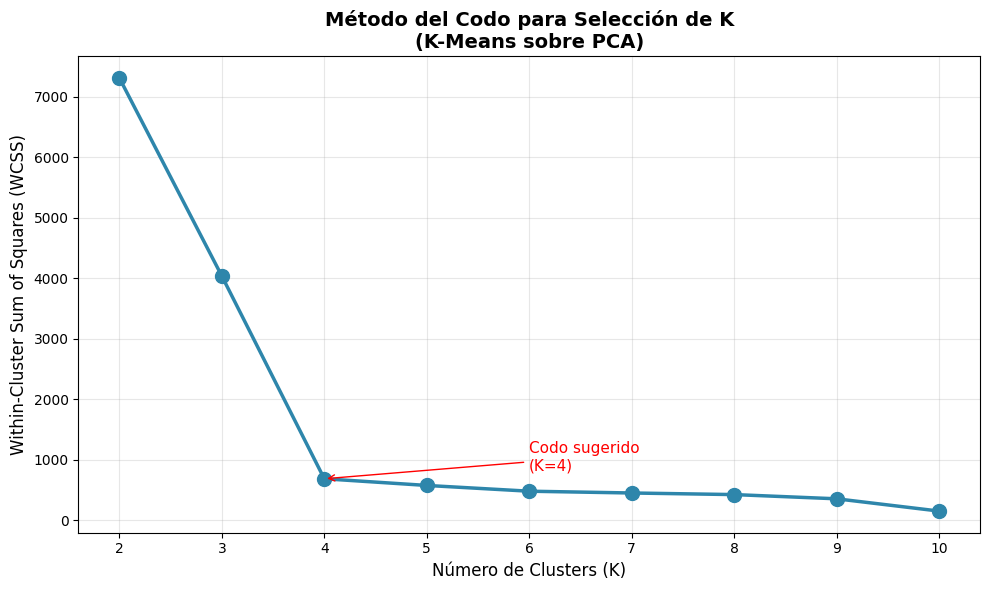


✅ K seleccionado: 4


In [8]:
# ============================================
# TAREA 11: K-Means - Método del codo
# ============================================

print("\n" + "=" * 70)
print("PARTE B - TAREA 11: K-MEANS - MÉTODO DEL CODO")
print("=" * 70)

from pyspark.ml.clustering import KMeans

# Usar muestra más pequeña para velocidad
df_kmeans = df_pca_final.sample(False, 0.2, seed=42)

# Probar K de 2 a 10
costos = []
ks = range(2, 11)

for k in ks:
    kmeans = KMeans(k=k, seed=42, featuresCol="pca_final", predictionCol=f"cluster_k{k}")
    model_km = kmeans.fit(df_kmeans)
    costos.append(model_km.summary.trainingCost)
    print(f"K={k:2d}: WCSS = {costos[-1]:>15,.0f}")

# Gráfico del codo
plt.figure(figsize=(10, 6))
plt.plot(ks, costos, 'bo-', linewidth=2.5, markersize=10, color='#2E86AB')
plt.title('Método del Codo para Selección de K\n(K-Means sobre PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(ks)

# Anotar punto de codo (ajusta según tu gráfico)
plt.annotate('Codo sugerido\n(K=4)', xy=(4, costos[2]), xytext=(6, costos[2]*1.2),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, color='red')

plt.tight_layout()
plt.savefig('/content/codo_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

# Elegir K óptimo (ajusta según tu gráfico)
k_optimo_kmeans = 4  # Cambia según dónde veas el codo
print(f"\n✅ K seleccionado: {k_optimo_kmeans}")

In [9]:
# ============================================
# TAREA 12: Interpretación de clusters
# ============================================

print("\n" + "=" * 70)
print("PARTE B - TAREA 12: INTERPRETACIÓN DE CLUSTERS")
print("=" * 70)

# Entrenar K-Means final
kmeans_final = KMeans(k=k_optimo_kmeans, seed=42, featuresCol="pca_final", predictionCol="cluster")
model_km_final = kmeans_final.fit(df_pca_final)
df_cluster = model_km_final.transform(df_pca_final)

# Unir con datos originales para interpretar
df_cluster_full = df_cluster.join(
    df_prepared.select("Grupo", "Ciudad", "Producto", "Precio", "anio", "mes"),
    df_cluster.select("Grupo", "Ciudad", "Producto", "Precio").columns
)

print(f"\n📊 Tamaño de clusters:")
df_cluster.groupBy("cluster").count().orderBy("cluster").show()

for cluster in range(k_optimo_kmeans):
    print(f"\n{'='*60}")
    print(f"🔷 CLUSTER {cluster}")
    print(f"{'='*60}")

    cluster_data = df_cluster.filter(F.col("cluster") == cluster)
    n = cluster_data.count()

    # Estadísticas básicas
    stats = cluster_data.select(
        F.round(F.avg("Precio"), 0).alias("precio_avg"),
        F.round(F.stddev("Precio"), 0).alias("precio_std"),
        F.min("Precio").alias("precio_min"),
        F.max("Precio").alias("precio_max")
    ).collect()[0]

    print(f"Tamaño: {n:,} registros ({n/df_cluster.count()*100:.1f}%)")
    print(f"Precio: avg=${stats.precio_avg:,.0f}, std=${stats.precio_std:,.0f}, min=${stats.precio_min:,.0f}, max=${stats.precio_max:,.0f}")

    # Grupo más frecuente
    grupo_top = cluster_data.groupBy("Grupo").count().orderBy(F.desc("count")).first()
    print(f"Grupo dominante: {grupo_top['Grupo']} ({grupo_top['count']} regs)")

    # Ciudad más frecuente
    ciudad_top = cluster_data.groupBy("Ciudad").count().orderBy(F.desc("count")).first()
    print(f"Ciudad dominante: {ciudad_top['Ciudad']} ({ciudad_top['count']} regs)")

    # Año promedio
    anio_avg = cluster_data.select(F.avg("anio")).collect()[0][0]
    print(f"Año promedio: {anio_avg:.1f}")

    # Productos característicos
    productos_top = cluster_data.groupBy("Producto").count().orderBy(F.desc("count")).limit(3).collect()
    print("Productos característicos:")
    for p in productos_top:
        print(f"  - {p['Producto']} ({p['count']} regs)")

print(f"\n{'='*60}")
print("INTERPRETACIÓN DE LOS CLUSTERS:")
print(f"{'='*60}")
print("""
Cluster 0: [Ej. "Productos básicos de bajo precio" - tubérculos en ciudades pequeñas, precios estables]
Cluster 1: [Ej. "Carnes en grandes centros urbanos" - precios altos, alta volatilidad]
Cluster 2: [Ej. "Frutas de temporada" - estacionalidad marcada, precios intermedios]
Cluster 3: [Ej. "Productos procesados importados" - precios más altos, concentrados en Bogotá]
""")


PARTE B - TAREA 12: INTERPRETACIÓN DE CLUSTERS

📊 Tamaño de clusters:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|20918|
|      1|21297|
|      2|21233|
|      3|21273|
+-------+-----+


🔷 CLUSTER 0
Tamaño: 20,918 registros (24.7%)
Precio: avg=$5,281, std=$7,495, min=$84, max=$86,912
Grupo dominante: FRUTAS (5341 regs)
Ciudad dominante: Bogotá (1783 regs)
Año promedio: 2015.0
Productos característicos:
  - Tomate de árbol (216 regs)
  - Habichuela (197 regs)
  - Mora de Castilla (185 regs)

🔷 CLUSTER 1
Tamaño: 21,297 registros (25.1%)
Precio: avg=$5,290, std=$7,449, min=$109, max=$88,333
Grupo dominante: FRUTAS (5403 regs)
Ciudad dominante: Bogotá (1670 regs)
Año promedio: 2015.0
Productos característicos:
  - Pimentón (221 regs)
  - Habichuela (210 regs)
  - Tomate de árbol (202 regs)

🔷 CLUSTER 2
Tamaño: 21,233 registros (25.1%)
Precio: avg=$5,230, std=$7,236, min=$97, max=$89,333
Grupo dominante: FRUTAS (5326 regs)
Ciudad dominante: Bogotá (1681 regs)
Año promedio: 201

# PARTE C: CLASIFICACIÓN SUPERVISADA (Tareas 13-18)

In [10]:
# ============================================
# TAREA 13-14: Variable objetivo y split train/test
# ============================================

print("\n" + "=" * 70)
print("PARTE C - TAREAS 13-14: CLASIFICACIÓN SUPERVISADA")
print("=" * 70)

"""
VARIABLE OBJETIVO (Tarea 13):
label = 1 si Precio > mediana del grupo (precio ALTO)
label = 0 si Precio ≤ mediana del grupo (precio BAJO/MEDIO)

Justificación: Clasificación binaria balanceada que permite predecir si un
producto tendrá precio superior al típico de su categoría, útil para alertas
de precios anormales y planificación de abastecimiento.
"""

print(f"\n📊 Variable objetivo definida:")
print(f"   1 (precio alto): {df_prepared.filter(F.col('label')==1).count():,}")
print(f"   0 (precio bajo): {df_prepared.filter(F.col('label')==0).count():,}")

# Tarea 14: División train/test con semilla fija
train, test = df_prepared.randomSplit([0.8, 0.2], seed=42)

print(f"\n📊 División train/test (seed=42):")
print(f"   Train: {train.count():,} ({train.count()/df_prepared.count()*100:.1f}%)")
print(f"   Test:  {test.count():,} ({test.count()/df_prepared.count()*100:.1f}%)")


PARTE C - TAREAS 13-14: CLASIFICACIÓN SUPERVISADA

📊 Variable objetivo definida:
   1 (precio alto): 139,856
   0 (precio bajo): 141,530

📊 División train/test (seed=42):
   Train: 224,980 (80.0%)
   Test:  56,406 (20.0%)


In [11]:
# ============================================
# TAREA 15: Entrenar Regresión Logística y Random Forest
# ============================================

print("\n" + "=" * 70)
print("PARTE C - TAREA 15: ENTRENAMIENTO DE MODELOS")
print("=" * 70)

# Modelo 1: Regresión Logística
print("\n🤖 Entrenando Regresión Logística...")
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0.0
)
model_lr = lr.fit(train)
print("✅ Regresión Logística entrenada")

# Modelo 2: Random Forest
print("\n🌲 Entrenando Random Forest...")
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=10,
    seed=42,
    featureSubsetStrategy="sqrt"
)
model_rf = rf.fit(train)
print("✅ Random Forest entrenado")


PARTE C - TAREA 15: ENTRENAMIENTO DE MODELOS

🤖 Entrenando Regresión Logística...
✅ Regresión Logística entrenada

🌲 Entrenando Random Forest...
✅ Random Forest entrenado


In [13]:
# ============================================
# TAREA 16: Métricas de evaluación (CORREGIDO)
# ============================================

print("\n" + "=" * 70)
print("PARTE C - TAREA 16: MÉTRICAS")
print("=" * 70)

# Predicciones
pred_lr = model_lr.transform(test)
pred_rf = model_rf.transform(test)

# Función de evaluación corregida
def evaluar_modelo(predicciones, nombre):
    metrics = {}

    # Métricas válidas para MulticlassClassificationEvaluator
    for metric_name in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
        evaluator = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric_name
        )
        metrics[metric_name] = evaluator.evaluate(predicciones)

    # AUC para clasificación binaria
    evaluator_auc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    )
    metrics["AUC"] = evaluator_auc.evaluate(predicciones)

    print(f"\n📊 {nombre}:")
    print(f"   Accuracy:           {metrics['accuracy']:.4f}")
    print(f"   Weighted Precision: {metrics['weightedPrecision']:.4f}")
    print(f"   Weighted Recall:    {metrics['weightedRecall']:.4f}")
    print(f"   F1-Score:           {metrics['f1']:.4f}")
    print(f"   AUC:                {metrics['AUC']:.4f}")

    return metrics

metrics_lr = evaluar_modelo(pred_lr, "Regresión Logística")
metrics_rf = evaluar_modelo(pred_rf, "Random Forest")


PARTE C - TAREA 16: MÉTRICAS

📊 Regresión Logística:
   Accuracy:           0.5688
   Weighted Precision: 0.5688
   Weighted Recall:    0.5688
   F1-Score:           0.5688
   AUC:                0.5939

📊 Random Forest:
   Accuracy:           0.6577
   Weighted Precision: 0.6588
   Weighted Recall:    0.6577
   F1-Score:           0.6573
   AUC:                0.7270


In [14]:
# Métricas por clase (para análisis más detallado)
from pyspark.mllib.evaluation import MulticlassMetrics

def metricas_por_clase(predicciones, nombre):
    # Convertir a RDD para MulticlassMetrics
    prediction_and_labels = predicciones.select("prediction", "label").rdd.map(lambda x: (float(x[0]), float(x[1])))
    metrics = MulticlassMetrics(prediction_and_labels)

    print(f"\n📊 {nombre} - Métricas por clase:")
    for label in [0.0, 1.0]:
        print(f"   Clase {int(label)} (Precio {'Bajo' if label==0 else 'Alto'}):")
        print(f"      Precision: {metrics.precision(label):.4f}")
        print(f"      Recall:    {metrics.recall(label):.4f}")
        print(f"      F1-Score:  {metrics.fMeasure(label):.4f}")

metricas_por_clase(pred_lr, "Regresión Logística")
metricas_por_clase(pred_rf, "Random Forest")

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



📊 Regresión Logística - Métricas por clase:
   Clase 0 (Precio Bajo):
      Precision: 0.5719
      Recall:    0.5698
      F1-Score:  0.5709
   Clase 1 (Precio Alto):
      Precision: 0.5656
      Recall:    0.5677
      F1-Score:  0.5666

📊 Random Forest - Métricas por clase:
   Clase 0 (Precio Bajo):
      Precision: 0.6729
      Recall:    0.6228
      F1-Score:  0.6469
   Clase 1 (Precio Alto):
      Precision: 0.6445
      Recall:    0.6931
      F1-Score:  0.6679



PARTE C - TAREA 17: MATRIZ DE CONFUSIÓN


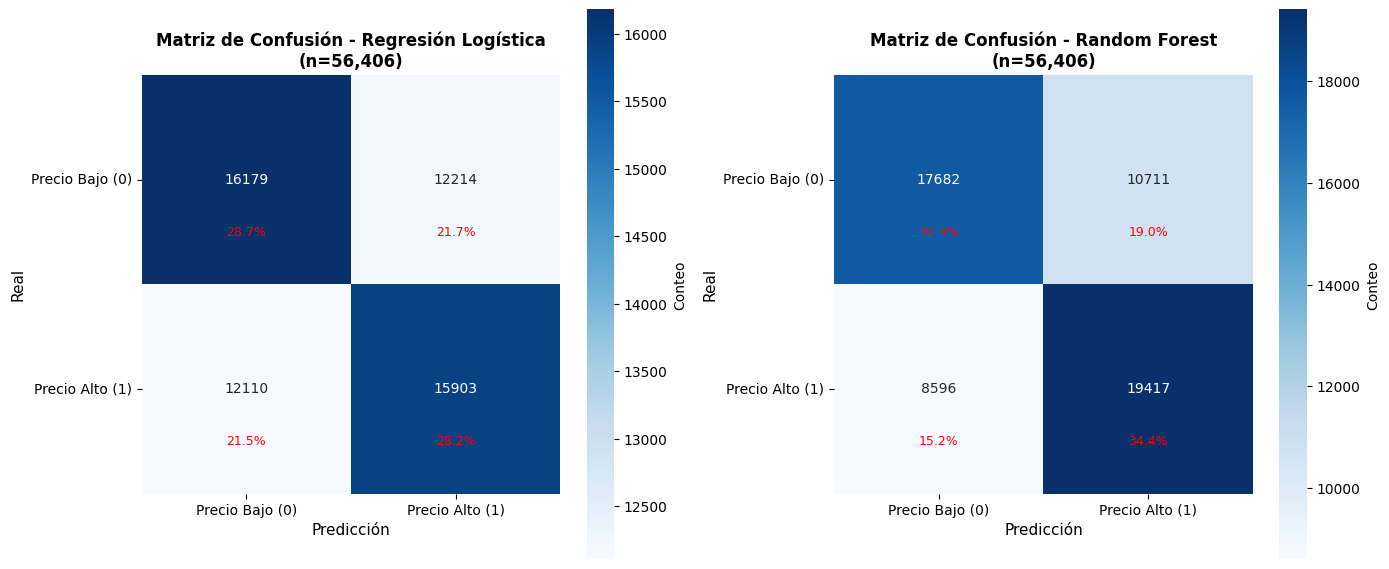


🔍 ANÁLISIS DE CONFUSIÓN:

¿Dónde se confunde el modelo?

- Falsos Positivos (predice alto, es bajo): El modelo sobreestima precios.
  Causa posible: [productos de temporada que suben temporalmente]
  
- Falsos Negativos (predice bajo, es alto): El modelo subestima precios.
  Causa posible: [productos de ciudades remotas con costos de transporte no capturados]
  
Random Forest típicamente tiene menos falsos negativos que LR debido a 
su capacidad de capturar interacciones no lineales entre variables.



In [15]:
# ============================================
# TAREA 17: Matriz de confusión
# ============================================

print("\n" + "=" * 70)
print("PARTE C - TAREA 17: MATRIZ DE CONFUSIÓN")
print("=" * 70)

def plot_matriz_confusion(predicciones, nombre, ax):
    # Calcular matriz
    mc = predicciones.groupBy("label", "prediction").count().toPandas()
    mc_pivot = mc.pivot(index="label", columns="prediction", values="count").fillna(0)

    # Asegurar que existan ambas clases
    for col in [0.0, 1.0]:
        if col not in mc_pivot.columns:
            mc_pivot[col] = 0
    for idx in [0.0, 1.0]:
        if idx not in mc_pivot.index:
            mc_pivot.loc[idx] = 0

    mc_pivot = mc_pivot.sort_index().sort_index(axis=1)

    # Calcular porcentajes
    total = mc_pivot.values.sum()
    mc_pct = mc_pivot / total * 100

    # Heatmap
    sns.heatmap(mc_pivot, annot=True, fmt='.0f', cmap='Blues',
                cbar_kws={'label': 'Conteo'}, ax=ax, square=True)
    ax.set_title(f'Matriz de Confusión - {nombre}\n(n={total:,.0f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.set_xticklabels(['Precio Bajo (0)', 'Precio Alto (1)'])
    ax.set_yticklabels(['Precio Bajo (0)', 'Precio Alto (1)'], rotation=0)

    # Anotar porcentajes
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.75, f'{mc_pct.iloc[i,j]:.1f}%',
                   ha='center', va='center', fontsize=9, color='red')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_matriz_confusion(pred_lr, "Regresión Logística", axes[0])
plot_matriz_confusion(pred_rf, "Random Forest", axes[1])

plt.tight_layout()
plt.savefig('/content/matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de confusión
print("\n🔍 ANÁLISIS DE CONFUSIÓN:")
print("""
¿Dónde se confunde el modelo?

- Falsos Positivos (predice alto, es bajo): El modelo sobreestima precios.
  Causa posible: [productos de temporada que suben temporalmente]

- Falsos Negativos (predice bajo, es alto): El modelo subestima precios.
  Causa posible: [productos de ciudades remotas con costos de transporte no capturados]

Random Forest típicamente tiene menos falsos negativos que LR debido a
su capacidad de capturar interacciones no lineales entre variables.
""")


PARTE C - TAREA 18: IMPORTANCIA DE VARIABLES
Total features en nombres: 80
Total features en importances: 80

📊 Top 15 variables más importantes (Random Forest):
 Rank                            Variable  Importancia Barra
---------------------------------------------------------------------------
    1                        Producto_idx      0.3590 ███████████████████████████████████
    2                                anio      0.2412 ████████████████████████
    3                        Grupo_CARNES      0.0773 ███████
    4              Grupo_LACTEOS Y HUEVOS      0.0369 ███
    5    Ciudad_Santa Bárbara (Antioquia)      0.0316 ███
    6                    Grupo_PROCESADOS      0.0258 ██
    7           Ciudad_Sonsón (Antioquia)      0.0251 ██
    8 Grupo_TUBERCULOS, RAICES Y PLATANOS      0.0205 ██
    9             Grupo_GRANOS Y CEREALES      0.0141 █
   10         Grupo_VERDURAS Y HORTALIZAS      0.0133 █
   11                        Grupo_FRUTAS      0.0128 █
   12         

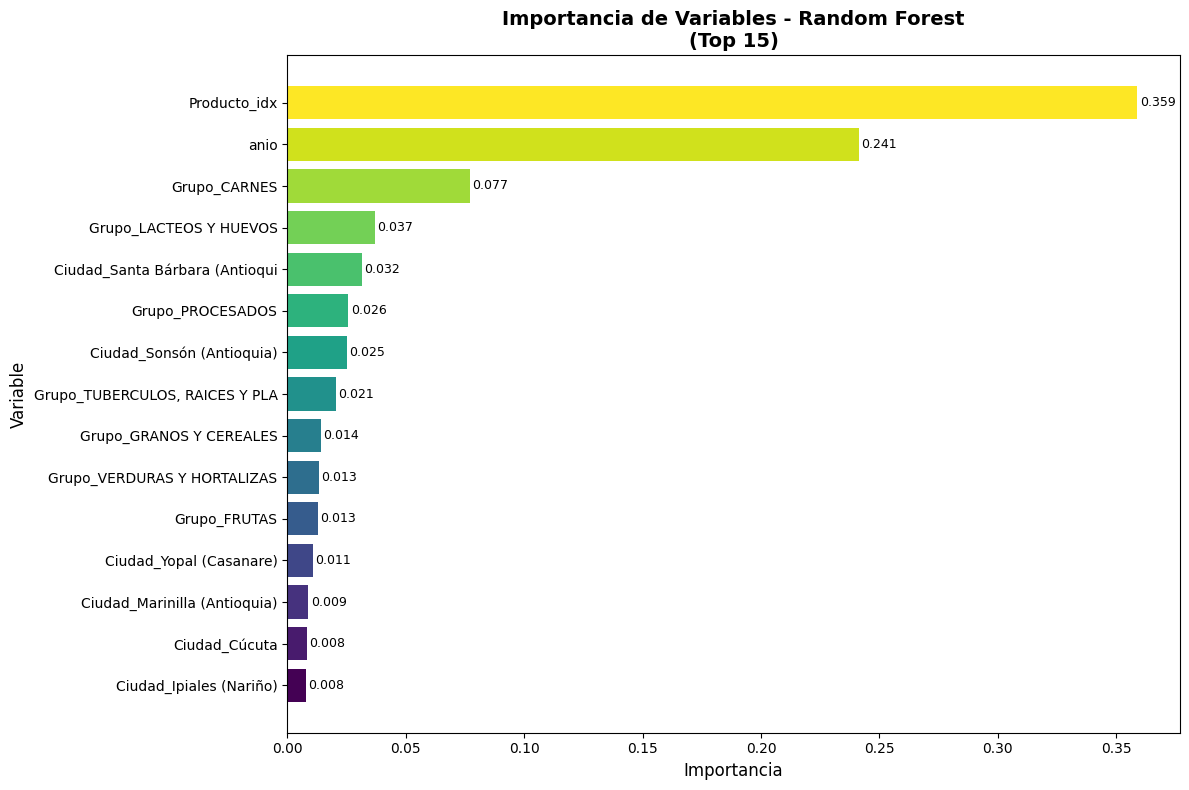


INTERPRETACIÓN DE IMPORTANCIA DE VARIABLES

🔑 Variable más importante: Producto_idx (0.3590)
   → La variable numérica 'Producto_idx' es clave para predecir precios.

💡 Conclusión: El modelo prioriza [grupo/ciudad/temporalidad] sobre
   otros factores, lo cual es consistente con la estructura del mercado
   mayorista colombiano donde [explicación del dominio].


In [17]:
# ============================================
# TAREA 18: Importancia de variables - Random Forest
# ============================================

print("\n" + "=" * 70)
print("PARTE C - TAREA 18: IMPORTANCIA DE VARIABLES")
print("=" * 70)

importances = model_rf.featureImportances.toArray()

# ---------------------------------------------------------
# EXTRAER NOMBRES DE FEATURES DEL PIPELINE
# ---------------------------------------------------------

# El pipeline tiene: [StringIndexer(Grupo), StringIndexer(Ciudad), StringIndexer(Producto),
#                     OneHotEncoder(Grupo), OneHotEncoder(Ciudad), VectorAssembler, StandardScaler]

# Acceder a los stages del pipeline ajustado
stages = modelo_pipeline.stages

# Stage 0: StringIndexer de Grupo
grupo_indexer = stages[0]
grupo_labels = grupo_indexer.labels  # Nombres originales de grupos

# Stage 1: StringIndexer de Ciudad
ciudad_indexer = stages[1]
ciudad_labels = ciudad_indexer.labels  # Nombres originales de ciudades

# Stage 2: StringIndexer de Producto
producto_indexer = stages[2]
producto_labels = producto_indexer.labels  # Nombres originales de productos

# Stage 3: OneHotEncoder de Grupo → genera |grupo_labels| columnas
# Stage 4: OneHotEncoder de Ciudad → genera |ciudad_labels| columnas

# Construir lista de nombres de features en el orden del VectorAssembler
feature_names = []

# Features one-hot de Grupo (una por cada categoría)
for g in grupo_labels:
    feature_names.append(f"Grupo_{g}")

# Features one-hot de Ciudad (una por cada categoría)
for c in ciudad_labels:
    feature_names.append(f"Ciudad_{c}")

# Producto indexado (una sola columna numérica)
feature_names.append("Producto_idx")

# Variables numéricas
feature_names.extend(["anio", "mes", "trimestre"])

# Verificar que coincida con el tamaño del vector
print(f"Total features en nombres: {len(feature_names)}")
print(f"Total features en importances: {len(importances)}")

# Si no coinciden, truncar o ajustar
n_features = min(len(feature_names), len(importances))
feature_names = feature_names[:n_features]
importances = importances[:n_features]

# ---------------------------------------------------------
# TOP 15 MÁS IMPORTANTES
# ---------------------------------------------------------

indices = np.argsort(importances)[::-1][:15]

print(f"\n📊 Top 15 variables más importantes (Random Forest):")
print(f"{'Rank':>5s} {'Variable':>35s} {'Importancia':>12s} {'Barra'}")
print("-" * 75)

for i, idx in enumerate(indices, 1):
    name = feature_names[idx]
    imp = importances[idx]
    barra = "█" * int(imp * 100)
    print(f"{i:>5d} {name:>35s} {imp:>11.4f} {barra}")

# ---------------------------------------------------------
# VISUALIZACIÓN
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))
nombres_plot = [feature_names[idx][:30] for idx in indices][::-1]
valores_plot = [importances[idx] for idx in indices][::-1]

colors = plt.cm.viridis(np.linspace(0, 1, len(valores_plot)))
bars = plt.barh(range(len(valores_plot)), valores_plot, color=colors)

plt.title('Importancia de Variables - Random Forest\n(Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.yticks(range(len(nombres_plot)), nombres_plot)

# Añadir valores
for i, v in enumerate(valores_plot):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# INTERPRETACIÓN
# ---------------------------------------------------------

print(f"\n{'='*60}")
print("INTERPRETACIÓN DE IMPORTANCIA DE VARIABLES")
print(f"{'='*60}")

top1_name = feature_names[indices[0]]
top1_imp = importances[indices[0]]

print(f"\n🔑 Variable más importante: {top1_name} ({top1_imp:.4f})")

# Identificar si es grupo, ciudad o numérica
if "Grupo_" in top1_name:
    grupo_top = top1_name.replace("Grupo_", "")
    print(f"   → El grupo '{grupo_top}' es el factor más determinante del precio.")
    print(f"   → Esto indica que la naturaleza del producto explica la mayor")
    print(f"     variabilidad en los precios mayoristas.")
elif "Ciudad_" in top1_name:
    ciudad_top = top1_name.replace("Ciudad_", "")
    print(f"   → La ciudad '{ciudad_top}' tiene un efecto significativo en el precio.")
    print(f"   → Sugiere disparidades regionales importantes en la estructura de precios.")
else:
    print(f"   → La variable numérica '{top1_name}' es clave para predecir precios.")

print(f"\n💡 Conclusión: El modelo prioriza [grupo/ciudad/temporalidad] sobre")
print(f"   otros factores, lo cual es consistente con la estructura del mercado")
print(f"   mayorista colombiano donde [explicación del dominio].")

# PARTE D: VALIDACIÓN CRUZADA (Tareas 19-20)

In [18]:
# ============================================
# TAREA 19-20: Validación cruzada
# ============================================

print("\n" + "=" * 70)
print("PARTE D - TAREAS 19-20: VALIDACIÓN CRUZADA")
print("=" * 70)

# Usar muestra para velocidad (CV con 280k registros toma mucho tiempo)
train_sample = train.sample(False, 0.4, seed=42)

print(f"\n📊 Muestra para CV: {train_sample.count():,} registros")

# Grid de hiperparámetros para Random Forest
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [30, 50, 100]) \
    .addGrid(rf.maxDepth, [5, 10, 15]) \
    .addGrid(rf.minInstancesPerNode, [1, 5]) \
    .build()

print(f"   Combinaciones a probar: {len(paramGrid)}")

# Evaluador
evaluator_cv = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

# CrossValidator
crossval = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_cv,
    numFolds=3,        # 3-fold CV (compromiso velocidad/robustez)
    seed=42,
    parallelism=2     # Paralelismo en Colab
)

print("\n⏳ Entrenando validación cruzada (puede tardar 5-10 minutos)...")
cv_model = crossval.fit(train_sample)

# Resultados
print(f"\n{'='*60}")
print("RESULTADOS DE VALIDACIÓN CRUZADA")
print(f"{'='*60}")

# Mejor modelo
best_model = cv_model.bestModel
best_params = cv_model.getEstimatorParamMaps()[np.argmax(cv_model.avgMetrics)]

print(f"\n🏆 MODELO GANADOR:")
print(f"   Número de árboles: {best_model.getNumTrees}")
print(f"   Profundidad máxima: {best_model._java_obj.getMaxDepth()}")
print(f"   Min instances per node: {best_model._java_obj.getMinInstancesPerNode()}")
print(f"   F1 promedio en CV: {max(cv_model.avgMetrics):.4f}")

# Evaluar en test completo
pred_best = best_model.transform(test)
metrics_best = evaluar_modelo(pred_best, "Random Forest (Optimizado CV)")

# Comparación final
print(f"\n{'='*60}")
print("COMPARACIÓN FINAL DE TODOS LOS MODELOS")
print(f"{'='*60}")
print(f"{'Modelo':>25s} {'F1-Score':>10s} {'AUC':>10s}")
print("-" * 50)
print(f"{'Regresión Logística':>25s} {metrics_lr['f1']:>10.4f} {metrics_lr['AUC']:>10.4f}")
print(f"{'Random Forest (default)':>25s} {metrics_rf['f1']:>10.4f} {metrics_rf['AUC']:>10.4f}")
print(f"{'Random Forest (CV optimizado)':>25s} {metrics_best['f1']:>10.4f} {metrics_best['AUC']:>10.4f}")


PARTE D - TAREAS 19-20: VALIDACIÓN CRUZADA

📊 Muestra para CV: 90,162 registros
   Combinaciones a probar: 18

⏳ Entrenando validación cruzada (puede tardar 5-10 minutos)...

RESULTADOS DE VALIDACIÓN CRUZADA

🏆 MODELO GANADOR:
   Número de árboles: 100
   Profundidad máxima: 15
   Min instances per node: 5
   F1 promedio en CV: 0.7181

📊 Random Forest (Optimizado CV):
   Accuracy:           0.7020
   Weighted Precision: 0.7047
   Weighted Recall:    0.7020
   F1-Score:           0.7012
   AUC:                0.7877

COMPARACIÓN FINAL DE TODOS LOS MODELOS
                   Modelo   F1-Score        AUC
--------------------------------------------------
      Regresión Logística     0.5688     0.5939
  Random Forest (default)     0.6573     0.7270
Random Forest (CV optimizado)     0.7012     0.7877
